# Reflection Spectra over Frequencies for Radar Design

In this example, we reproduce the result of Fig. 7 in the work [1].

[1] Eric Michielssen, Jean-Michel Sajer, S. Ranjithan, and Raj Mittra. [Design of lightweight, broad-band microwave absorbers using genetic algorithms](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=238519&casa_token=cAzTLiuvjPcAAAAA:iW8Ema9V9aE9lUAGOst4mGaeFeh45hGqOAJY1-ieAXdYcAqUmrNo1d3PpHUrecssvVvZzWK6rg&tag=1). *IEEE Transactions on Microwave Theory and Techniques*, vol. 41, no. 6, pp. 1024–1031, 1993.

First, the required packages are imported.

In [6]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as onp

import jaxlayerlumos as jll
import jaxlayerlumos.utils_materials as jll_utils_materials
import jaxlayerlumos.utils_units as jll_utils_units

We define frequencies from 0.1 GHz to 10 GHz and an incidence angle 0

In [7]:
freq_range = (0.1, 10)
inc_angle = 0.0

frequencies = jnp.linspace(freq_range[0] * jll_utils_units.get_giga(), freq_range[1] * jll_utils_units.get_giga(), 1000)
frequencies_in_ghz = onp.array(frequencies) / jll_utils_units.get_giga()

Radar designs suggested in the work [1] in Table II are specified. Then, the details of four radar designs are printed.

In [8]:
designs = [
    {
        "materials_data": ["16", "6", "5", "11", "2"],
        "thicknesses_in_mm": [0.486, 1.446, 1.272, 0.885, 1.155],
        "ref_R_in_db": -23.5
    },
    {
        "materials_data": ["16", "8", "5", "2", "13"],
        "thicknesses_in_mm": [0.537, 0.432, 0.261, 0.465, 0.975],
        "ref_R_in_db": -19.8
    },
    {
        "materials_data": ["16", "2", "15", "15", "14"],
        "thicknesses_in_mm": [0.588, 0.636, 0.477, 0.051, 0.009],
        "ref_R_in_db": -17
    },
    {
        "materials_data": ["14", "15", "9", "9", "9"],
        "thicknesses_in_mm": [0.273, 0.039, 0.435, 0.411, 0.078],
        "ref_R_in_db": -13
    }
]

for i, design in enumerate(designs):
    materials_data = design["materials_data"]
    thicknesses_in_mm = design["thicknesses_in_mm"]
    ref_R_in_db = design["ref_R_in_db"]

    materials = ["Air"] + materials_data + ["PEC"]
    thicknesses = jnp.array([0.0] + [thickness * jll_utils_units.get_milli() for thickness in thicknesses_in_mm] + [0.0])

    print(f"HF{i + 1}:")
    print("  Material layout:", materials)
    print("  Layer thicknesses (m):", thicknesses)
    print("  Reference R (db):", ref_R_in_db)

HF1:
  Material layout: ['Air', '16', '6', '5', '11', '2', 'PEC']
  Layer thicknesses (m): [0.       0.000486 0.001446 0.001272 0.000885 0.001155 0.      ]
  Reference R (db): -23.5
HF2:
  Material layout: ['Air', '16', '8', '5', '2', '13', 'PEC']
  Layer thicknesses (m): [0.       0.000537 0.000432 0.000261 0.000465 0.000975 0.      ]
  Reference R (db): -19.8
HF3:
  Material layout: ['Air', '16', '2', '15', '15', '14', 'PEC']
  Layer thicknesses (m): [0.00e+00 5.88e-04 6.36e-04 4.77e-04 5.10e-05 9.00e-06 0.00e+00]
  Reference R (db): -17
HF4:
  Material layout: ['Air', '14', '15', '9', '9', '9', 'PEC']
  Layer thicknesses (m): [0.00e+00 2.73e-04 3.90e-05 4.35e-04 4.11e-04 7.80e-05 0.00e+00]
  Reference R (db): -13


In the next cell, we compare our results to the reference results.

In [9]:
Rs_in_db = []
ref_Rs_in_db = []

for i, design in enumerate(designs):
    materials_data = design["materials_data"]
    thicknesses_in_mm = design["thicknesses_in_mm"]
    ref_R_in_db = design["ref_R_in_db"]

    materials = ["Air"] + materials_data + ["PEC"]
    thicknesses = jnp.array([0.0] + [thickness * jll_utils_units.get_milli() for thickness in thicknesses_in_mm] + [0.0])

    eps_stack, mu_stack = jll_utils_materials.get_eps_mu(materials, frequencies)
    R_TE, _, R_TM, _ = jll.stackrt_eps_mu(eps_stack, mu_stack, thicknesses, frequencies, inc_angle)
    R = (R_TE + R_TM) / 2.0
    R_in_db = 10 * jnp.log10(R).squeeze()

    print(f"HF{i + 1}: max(R_in_db) {onp.max(R_in_db):.2f} ref_R_in_db {ref_R_in_db:.2f}")
    Rs_in_db.append(R_in_db)
    ref_Rs_in_db.append(ref_R_in_db)

Rs_in_db = onp.array(Rs_in_db)
ref_Rs_in_db = onp.array(ref_Rs_in_db)

HF1: max(R_in_db) -5.77 ref_R_in_db -23.50
HF2: max(R_in_db) -1.21 ref_R_in_db -19.80
HF3: max(R_in_db) -0.04 ref_R_in_db -17.00
HF4: max(R_in_db) -0.16 ref_R_in_db -13.00


The results of reflection spectra over frequencies are plotted.

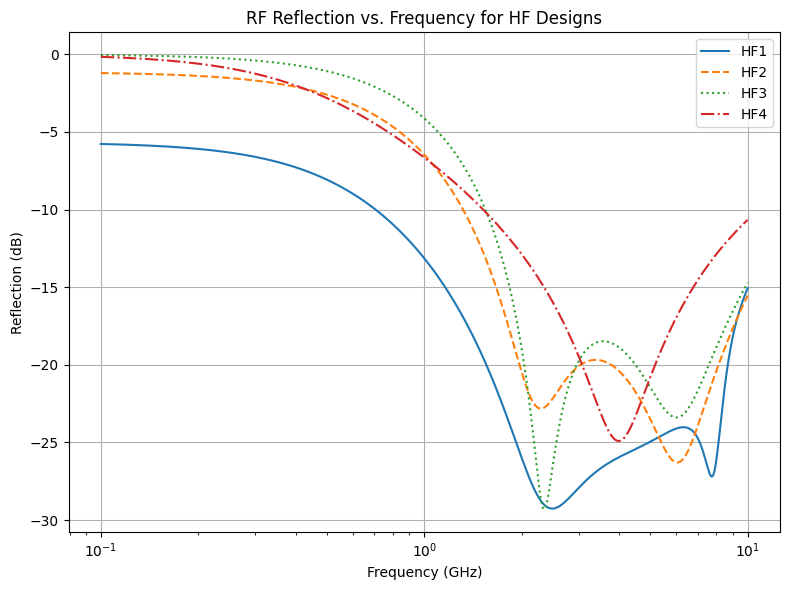

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = fig.gca()
line_styles = ['-', '--', ':', '-.']

for i, (R_in_db, ref_R_in_db) in enumerate(zip(Rs_in_db, ref_Rs_in_db)):
    ax.semilogx(
        frequencies_in_ghz,
        onp.array(R_in_db),
        line_styles[i % len(line_styles)], 
        label=f"HF{i + 1}"
    )

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflection (dB)")
ax.set_title("RF Reflection vs. Frequency for HF Designs")
ax.grid()

plt.legend()
plt.tight_layout()
plt.show()